# ANFIS & the F-transform

Train an ANFIS to approximate a function, and denoise a signal with the F-transform.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import fuzzytool as fz

## ANFIS approximating sin(x)

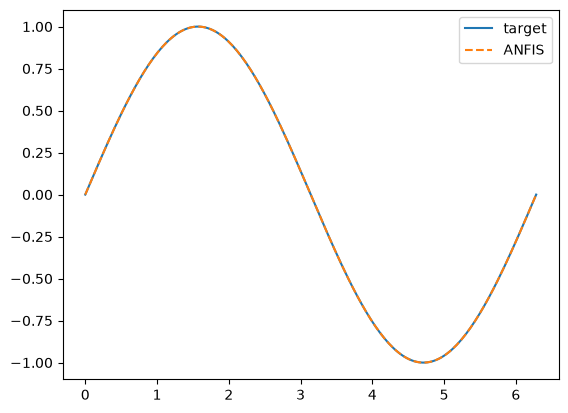

final RMSE: 4.967042628923904e-06


In [2]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)
model = fz.ANFIS(n_inputs=1, n_mf=6).fit(x[:, None], y, epochs=100)
plt.plot(x, y, label='target')
plt.plot(x, model.predict(x[:, None]), '--', label='ANFIS')
plt.legend(); plt.show()
print('final RMSE:', model.history_[-1])

## F-transform denoising

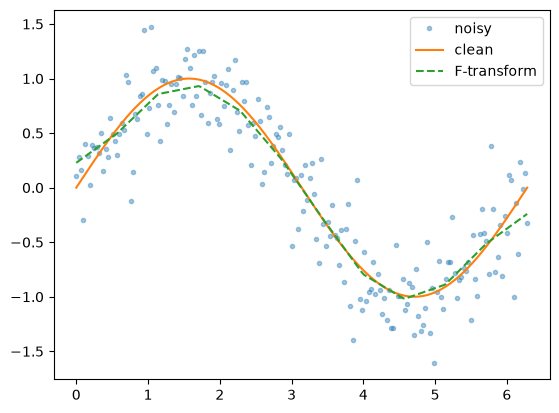

In [3]:
rng = np.random.default_rng(1)
clean = np.sin(x)
noisy = clean + rng.normal(0, 0.3, size=x.shape)
ft = fz.FTransform(0, 2 * np.pi, n_basis=12).fit(x, noisy)
plt.plot(x, noisy, '.', alpha=0.4, label='noisy')
plt.plot(x, clean, label='clean')
plt.plot(x, ft.smooth(x), '--', label='F-transform')
plt.legend(); plt.show()